<h1>Details(Audit) of all Datasets<h1>

<h4>1. nykaa_campaign_data <h4>

In [128]:
import pandas as pd
import numpy as np

nykaa_campaign_data = pd.read_csv('Marketing Campaign Dataset//nykaa_campaign_data.csv')
print(nykaa_campaign_data.head())

print(nykaa_campaign_data.info())

print(nykaa_campaign_data.describe())

   Campaign_ID Campaign_Type        Target_Audience  Duration  \
0  NY-CMP-1000  Social Media       College Students        21   
1  NY-CMP-1001      Paid Ads  Tier 2 City Customers        18   
2  NY-CMP-1002    Influencer                  Youth        23   
3  NY-CMP-1003         Email          Working Women        18   
4  NY-CMP-1004      Paid Ads       College Students        10   

                   Channel_Used  Impressions  Clicks  Leads  Conversions  \
0             WhatsApp, YouTube        57804    6156   3616         2355   
1                       YouTube        91801    3321   1971         1357   
2     WhatsApp, Google, YouTube        15536    2182    952          755   
3  YouTube, Facebook, Instagram        88114    8413   2231          947   
4           Facebook, Instagram        96871    3743   2060         1258   

   Revenue  Acquisition_Cost   ROI Language  Engagement_Score  \
0  1867515            111.03  6.14    Hindi             20.98   
1  1046247            

<h4> 2. tira_campaign_data <h4>

In [129]:
tira_campaign_data = pd.read_csv('Marketing Campaign Dataset//tira_campaign_data.csv')
print(tira_campaign_data.head())

print(tira_campaign_data.info())

print(tira_campaign_data.describe())

   Campaign_ID Campaign_Type        Target_Audience  Duration  \
0  TI-CMP-1000           SEO          Working Women        11   
1  TI-CMP-1001  Social Media  Tier 2 City Customers        24   
2  TI-CMP-1002      Paid Ads          Working Women        28   
3  TI-CMP-1003         Email                  Youth         8   
4  TI-CMP-1004      Paid Ads       Premium Shoppers        15   

                Channel_Used  Impressions  Clicks  Leads  Conversions  \
0                  Instagram        64004    2906   1639          952   
1                    YouTube        71795    2051    552          256   
2                  Instagram        79158    3546   1928         1314   
3                     Google        31523    3721   2088          736   
4  Facebook, Email, WhatsApp        61441    7277   3615         2602   

   Revenue  Acquisition_Cost   ROI Language  Engagement_Score  \
0   222768            129.72  0.80    Tamil              8.59   
1   199168            316.36  1.46    Ta

<h1>Cleaning of the Datasets<h1>

<h4>1. nykaa_campaign_data<h4>

In [130]:
print("Duplicated Values are:",nykaa_campaign_data.duplicated().sum())

print()

print(nykaa_campaign_data.isnull().sum())

nykaa_campaign_data.columns = nykaa_campaign_data.columns.str.strip()

nykaa_campaign_data['Date'] = pd.to_datetime(nykaa_campaign_data['Date'], format='%d-%m-%Y')

Duplicated Values are: 0

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64


<h4>2. tira_campaign_data<h4>

In [131]:
print("Duplicated Values are:",tira_campaign_data.duplicated().sum())

print()

print(tira_campaign_data.isnull().sum())

tira_campaign_data.columns = tira_campaign_data.columns.str.strip()

tira_campaign_data['Date'] = pd.to_datetime(tira_campaign_data['Date'], format='%d-%m-%Y')

Duplicated Values are: 0

Campaign_ID         0
Campaign_Type       0
Target_Audience     0
Duration            0
Channel_Used        0
Impressions         0
Clicks              0
Leads               0
Conversions         0
Revenue             0
Acquisition_Cost    0
ROI                 0
Language            0
Engagement_Score    0
Customer_Segment    0
Date                0
dtype: int64


<h1>Insights from the Data<h1>

<h4>1. What is Average Click Through Rate of both Nykaa and Tira ?<h4>

In [132]:
ny_clicks = nykaa_campaign_data['Clicks'].mean()

ny_Impressions = nykaa_campaign_data['Impressions'].mean()

ny_ctr = ny_clicks/ny_Impressions * 100
print(f'Nykaa Average click Through Rate is: {ny_ctr:.2f}')

ti_clicks = tira_campaign_data['Clicks'].mean()

ti_Impressions = tira_campaign_data['Impressions'].mean()

ti_ctr = (ti_clicks/ti_Impressions) * 100
print(f'Tira Average click Through Rate is: {ti_ctr:.2f}')

Nykaa Average click Through Rate is: 8.51
Tira Average click Through Rate is: 8.50


<h4>2. What are the Average waste leads rate of both Nykaa and Tira ?<h4>

In [133]:
ny_Leads = nykaa_campaign_data['Leads'].mean()

ny_Conversions = nykaa_campaign_data['Conversions'].mean()

ny_wleads = ny_Leads - ny_Conversions

nykaa_Waste_Rate = (ny_wleads / ny_Leads) * 100

print(f'Nykaa Waste Leads Rate are {nykaa_Waste_Rate:.2f}')

ti_Leads = tira_campaign_data['Leads'].mean()

ti_Conversions = tira_campaign_data['Conversions'].mean()

ti_wleads = ti_Leads - ti_Conversions

tira_Waste_Rate = (ti_wleads / ti_Leads) * 100

print(f'tira Waste Leads Rate are {tira_Waste_Rate:.2f}')

Nykaa Waste Leads Rate are 44.98
tira Waste Leads Rate are 45.03


<h4>3. Which Company is Spending More Money on Getting More Customers ?  (Nykaa or Tira)<h4>

In [134]:
import scipy.stats as stats

data = nykaa_campaign_data['Acquisition_Cost']
mean = data.mean()
se = stats.sem(data)

data2 = tira_campaign_data['Acquisition_Cost']
mean2 = data2.mean()
se2 = stats.sem(data2)

cin_95 = stats.t.interval(0.95, len(data)-1, loc=mean, scale=se)

cit_95 = stats.t.interval(0.95, len(data2)-1, loc=mean2, scale=se2)

print(f'Average customer Acquisition Cost of Nykaa is: {mean:.2f}')
print(f'Average customer Acquisition Cost of Tira is: {mean2:.2f}')

print(f"95% Interval of Nykaa's Customer Acquisition Cost: {cin_95}")

print(f"95% Interval of tira's Customer Acquisition Cost: {cit_95}")


Average customer Acquisition Cost of Nykaa is: 377.35
Average customer Acquisition Cost of Tira is: 374.28
95% Interval of Nykaa's Customer Acquisition Cost: (np.float64(372.84760075873254), np.float64(381.84653514262646))
95% Interval of tira's Customer Acquisition Cost: (np.float64(369.8753104338088), np.float64(378.6793517928135))


<h4>4. How much duartion of content on average gives high ROI , CTR, LEADS and CONVERSIONS ? (NYKAA and TIRA) <h4>

In [135]:
nykaa_campaign_data['CTR'] = nykaa_campaign_data['Clicks']/nykaa_campaign_data['Impressions'] * 100

tira_campaign_data['CTR'] = tira_campaign_data['Clicks']/tira_campaign_data['Impressions'] * 100

nykaa_duration_perf = nykaa_campaign_data.groupby('Duration')[['ROI', 'CTR','Leads','Conversions']].mean().sort_values(by='ROI', ascending=False)

tira_duration_perf = tira_campaign_data.groupby('Duration')[['ROI', 'CTR','Leads','Conversions']].mean().sort_values(by='ROI', ascending=False)

def find_best_duration(df, name):
    df_norm = (df - df.min()) / (df.max() - df.min()) # values in some columns are different, so squeezes every value into a range between 0 and 1.
  
    df['Total_Performance_Score'] = df_norm.mean(axis=1) #calculate the average across the row.
    
    sorted_df = df.sort_values(by='Total_Performance_Score', ascending=False)
    
    print(f"--- Top 3 Durations for {name} ---")
    print(sorted_df[['Total_Performance_Score']].head(3))
    return sorted_df

nykaa_final = find_best_duration(nykaa_duration_perf, "Nykaa")
tira_final = find_best_duration(tira_duration_perf, "Tira")

--- Top 3 Durations for Nykaa ---
          Total_Performance_Score
Duration                         
25                       0.975882
18                       0.804964
30                       0.799398
--- Top 3 Durations for Tira ---
          Total_Performance_Score
Duration                         
10                       1.000000
25                       0.867877
12                       0.859971


<h4>5. What is the True Skill level (ROI) of different top 10 channel_used ? (In April Month 2025) <h4>

<h4>A. Nykaa<h4>

In [136]:
start_date = '01-04-2025'
end_date = '30-04-2025'

mask = (nykaa_campaign_data['Date'] >= start_date) & (nykaa_campaign_data['Date'] <= end_date)

spring_season_df = nykaa_campaign_data.loc[mask]

channel_stats = spring_season_df.groupby('Channel_Used')['ROI'].mean().reset_index()

# Using tom tango method.

n = channel_stats['Channel_Used'].nunique() # The number of unique channels

p = nykaa_campaign_data['ROI'].mean()  # Base average is average of ROI in all full data.

obs_std = channel_stats['ROI'].std()

# Use the actual spread of the ROI data

luck_std = channel_stats['ROI'].std() / np.sqrt(n)

# Using this formula (observed standard deviation = skill standard deviation + luck standard deviation) to calculate skill standard devaition.

skill_std = obs_std - luck_std

reversion_adj = luck_std / skill_std

c = n / (n + reversion_adj)

# Using James-Stein Estimator Method

channel_stats['ROI_Truth_Average'] = p + c * (channel_stats['ROI'] - p)

print(f"Independent Trials (n): {n}")
print(f"True Skill STD: {skill_std:.4f}")

print(f"Your Reversion Adjustment: {reversion_adj:.2f}")
print(f"Your Shrinkage Factor (c): {c:.4f}")

top_channels = channel_stats.sort_values(by='ROI_Truth_Average', ascending=False)
print("--- (NYKAA) TOP 10 CHANNELS BY TRUE SKILL ---")
print(top_channels[['Channel_Used', 'ROI', 'ROI_Truth_Average']].head(10))

Independent Trials (n): 156
True Skill STD: 0.5283
Your Reversion Adjustment: 0.09
Your Shrinkage Factor (c): 0.9994
--- (NYKAA) TOP 10 CHANNELS BY TRUE SKILL ---
                    Channel_Used       ROI  ROI_Truth_Average
22      Email, YouTube, Facebook  4.764706           4.763562
17     Email, WhatsApp, Facebook  4.413333           4.412386
64      Google, Instagram, Email  4.403590           4.402648
24     Email, YouTube, Instagram  4.217273           4.216434
142       YouTube, Google, Email  4.180408           4.179590
35    Facebook, Google, WhatsApp  3.945208           3.944522
75     Google, YouTube, Facebook  3.927647           3.926970
2        Email, Facebook, Google  3.730357           3.729790
114  WhatsApp, Facebook, YouTube  3.683148           3.682608
39   Facebook, Instagram, Google  3.622353           3.621846


<H4>B. TIRA <H4>

In [137]:
start_date = '01-04-2025'
end_date = '30-04-2025'

mask1 = (tira_campaign_data['Date'] >= start_date) & (tira_campaign_data['Date'] <= end_date)

spring_season_df1 = tira_campaign_data.loc[mask1]

channel_stats1 = spring_season_df1.groupby('Channel_Used')['ROI'].mean().reset_index()

# Using tom tango method.

n1 = channel_stats1['Channel_Used'].nunique() # The number of unique channels

p1 = tira_campaign_data['ROI'].mean() # Base average is average of ROI in all full data.

obs_std1 = channel_stats1['ROI'].std()

# Use the actual spread of the ROI data

luck_std1 = channel_stats1['ROI'].std() / np.sqrt(n1)

# Using this formula (observed standard deviation = skill standard deviation + luck standard deviation) to calculate skill standard devaition.

skill_std1 = obs_std1 - luck_std1

reversion_adj1 = luck_std1 / skill_std1

c1 = n1 / (n1 + reversion_adj1)

print(f'-----------------------------------------------------------------------------------------')

# Using James-Stein Estimator Method

channel_stats1['ROI_Truth_Average'] = p1 + c1 * (channel_stats1['ROI'] - p1)

print(f"Independent Trials (n): {n1}")
print(f"True Skill STD: {skill_std1:.4f}")

print(f"Your Reversion Adjustment: {reversion_adj1:.2f}")
print(f"Your Shrinkage Factor (c): {c1:.4f}")

top_channels1 = channel_stats1.sort_values(by='ROI_Truth_Average', ascending=False)
print("--- (TIRA) TOP 10 CHANNELS BY TRUE SKILL ---")
print(top_channels1[['Channel_Used', 'ROI', 'ROI_Truth_Average']].head(10))

-----------------------------------------------------------------------------------------
Independent Trials (n): 156
True Skill STD: 0.5442
Your Reversion Adjustment: 0.09
Your Shrinkage Factor (c): 0.9994
--- (TIRA) TOP 10 CHANNELS BY TRUE SKILL ---
                     Channel_Used       ROI  ROI_Truth_Average
59        Google, Facebook, Email  4.798235           4.797051
86    Instagram, Facebook, Google  4.113469           4.112667
90       Instagram, Google, Email  4.085714           4.084928
34    Facebook, Google, Instagram  3.922381           3.921685
20       Email, WhatsApp, YouTube  3.877143           3.876473
155  YouTube, WhatsApp, Instagram  3.865417           3.864753
72      Google, WhatsApp, YouTube  3.803889           3.803259
123   WhatsApp, Instagram, Google  3.776949           3.776335
112    WhatsApp, Facebook, Google  3.739286           3.738692
148  YouTube, Instagram, Facebook  3.730769           3.730181


<H4>6. Which brands ROI performance is better ? Hypothesis Testing (Independent T test)  <H4> 

In [138]:
# 1. First, check if the variances are equal (Levene's Test)
# This helps us decide if we use a standard T-test or a Welch's T-test

stat, p_levene = stats.levene(nykaa_campaign_data['ROI'], tira_campaign_data['ROI'])
equal_var = True if p_levene > 0.05 else False
print(equal_var)

t_stat, p_value = stats.ttest_ind(nykaa_campaign_data['ROI'], tira_campaign_data['ROI'], equal_var=equal_var)

print(f"Nykaa Mean ROI: {nykaa_campaign_data['ROI'].mean():.4f}")
print(f"Tira Mean ROI: {tira_campaign_data['ROI'].mean():.4f}")
print(f"T-Statistic: {t_stat:.4f}")
print(f"P-Value: {p_value:.4f}")

alpha = 0.05
if p_value < alpha:
    print("\nVerdict: REJECT the Null Hypothesis.")
    if nykaa_campaign_data['ROI'].mean() > tira_campaign_data['ROI'].mean():
        print("Conclusion: Nykaa's ROI is statistically significantly HIGHER than Tira's.")
    else:
        print("Conclusion: Tira's ROI is statistically significantly HIGHER than Nykaa's.")
else:
    print("\nVerdict: FAIL TO REJECT the Null Hypothesis.")
    print("Conclusion: The difference is not statistically significant. Any difference seen is likely due to random chance.")

True
Nykaa Mean ROI: 2.7138
Tira Mean ROI: 2.6750
T-Statistic: 1.4441
P-Value: 0.1487

Verdict: FAIL TO REJECT the Null Hypothesis.
Conclusion: The difference is not statistically significant. Any difference seen is likely due to random chance.


<h4>7. Based on Average Metrics like ROI , CTR , Conversions , Waste Leads Who Will Perform better in the 10,000 simulations.(Monte Carlo Simulation) <h4>

In [139]:
# 1. Setup Simulation
n_sims = 10000

def get_brand_stats(df):
    # We calculate the conversion rate for EVERY campaign to get the correct Mean and StdDev
    # This captures the "noise" and "reliability" of their conversions
    conv_rates = df['Conversions'] / df['Leads']
    
    return {
        'roi_mu': df['ROI'].mean(), 'roi_sigma': df['ROI'].std(),
        'ctr_mu': (df['Clicks']/df['Impressions']).mean()*100, 'ctr_sigma': (df['Clicks']/df['Impressions']).std()*100,
        'leads_mu': df['Leads'].mean(), 'leads_sigma': df['Leads'].std(),
        'cvr_mu': conv_rates.mean(), 'cvr_sigma': conv_rates.std()
    }

n_stats = get_brand_stats(nykaa_campaign_data)
t_stats = get_brand_stats(tira_campaign_data)

# 2. Run the Funnel-Correct Simulation
# Nykaa
ny_roi = np.random.normal(n_stats['roi_mu'], n_stats['roi_sigma'], n_sims)
ny_ctr = np.random.normal(n_stats['ctr_mu'], n_stats['ctr_sigma'], n_sims)
ny_leads_total = np.random.normal(n_stats['leads_mu'], n_stats['leads_sigma'], n_sims)
ny_cvr = np.random.normal(n_stats['cvr_mu'], n_stats['cvr_sigma'], n_sims)

ny_conv = ny_leads_total * ny_cvr
ny_waste = ny_leads_total * (1 - ny_cvr)

# Tira
ti_roi = np.random.normal(t_stats['roi_mu'], t_stats['roi_sigma'], n_sims)
ti_ctr = np.random.normal(t_stats['ctr_mu'], t_stats['ctr_sigma'], n_sims)
ti_leads_total = np.random.normal(t_stats['leads_mu'], t_stats['leads_sigma'], n_sims)
ti_cvr = np.random.normal(t_stats['cvr_mu'], t_stats['cvr_sigma'], n_sims) # Fixed name here

ti_conv = ti_leads_total * ti_cvr
ti_waste = ti_leads_total * (1 - ti_cvr)

# 3. Decision Scoreboard
results = {
    'Metric': ['ROI', 'CTR', 'Conversions', 'Waste Leads'],
    'Nykaa Win %': [
        (ny_roi > ti_roi).mean()*100,
        (ny_ctr > ti_ctr).mean()*100,
        (ny_conv > ti_conv).mean()*100,
        (ny_waste < ti_waste).mean()*100 
    ]
}

scoreboard = pd.DataFrame(results)
scoreboard['Tira Win %'] = 100 - scoreboard['Nykaa Win %']
print(scoreboard)

        Metric  Nykaa Win %  Tira Win %
0          ROI        50.32       49.68
1          CTR        50.98       49.02
2  Conversions        50.13       49.87
3  Waste Leads        50.04       49.96


<h1>Visualization<h1>

<h4>1. What is Average Click Through Rate of both Nykaa and Tira ?<h4>

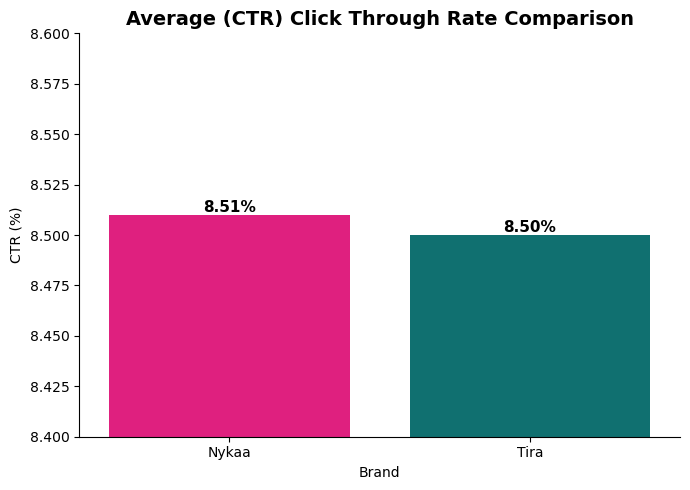

<Figure size 640x480 with 0 Axes>

In [140]:
import matplotlib.pyplot as plt
import seaborn as sns

data = {
    'Brand': ['Nykaa', 'Tira'],
    'Metric': [8.51, 8.50]
}
df = pd.DataFrame(data)

plt.figure(figsize=(7, 5))
ax = sns.barplot(x='Brand', y='Metric', data=df, palette=['#ff007f', '#008080'], hue='Brand', legend=False)

# For Add Value Labels (The numbers on top of the bars)
for p in ax.patches:
    ax.annotate(f'{p.get_height():.2f}%', 
                (p.get_x() + p.get_width() / 2., p.get_height()), 
                ha='center', va='bottom', fontsize=11, fontweight='bold')


plt.title('Average (CTR) Click Through Rate Comparison', fontsize=14, fontweight='bold')
plt.ylabel('CTR (%)')
plt.ylim(8.4, 8.6)  # Use this to 'zoom' into small differences
sns.despine()       # Removes the top and right borders for a cleaner look

plt.tight_layout()
plt.show()
plt.savefig('avg_ctr.png')

<h4>2. What are the Average waste leads rate of both Nykaa and Tira ? <h4>

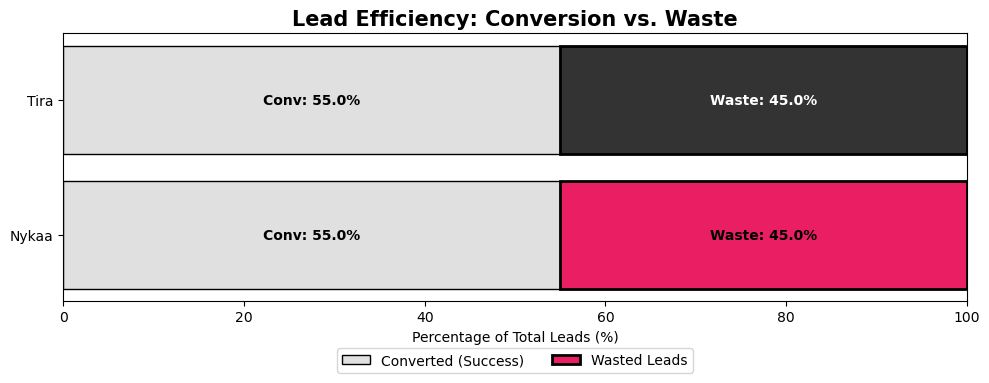

<Figure size 640x480 with 0 Axes>

In [141]:
# Derived data
ny_success = 100 - nykaa_Waste_Rate
ti_success = 100 - tira_Waste_Rate

brands = ['Nykaa', 'Tira']
success_rates = [ny_success, ti_success]
waste_rates = [nykaa_Waste_Rate, tira_Waste_Rate]

fig, ax = plt.subplots(figsize=(10, 4))

ax.barh(brands, success_rates, label='Converted (Success)', color='#E0E0E0', edgecolor='black')
ax.barh(brands, waste_rates, left=success_rates, label='Wasted Leads', color=['#e91e63', '#333333'], edgecolor='black', linewidth=2)

# Adding labels
for i, (s, w) in enumerate(zip(success_rates, waste_rates)):
    ax.text(s + w/2, i, f'Waste: {w:.1f}%', ha='center', va='center', color='white' if i==1 else 'black', fontweight='bold')
    ax.text(s/2, i, f'Conv: {s:.1f}%', ha='center', va='center', color='black', fontweight='bold')

plt.title('Lead Efficiency: Conversion vs. Waste', fontsize=15, fontweight='bold')
plt.xlabel('Percentage of Total Leads (%)')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15), ncol=2)
plt.xlim(0, 100)
plt.tight_layout()
plt.show()
plt.savefig('conv_waste.png')

<h4>3. Which Company is Spending More Money on Getting More Customers ? (Nykaa or Tira)<h4>

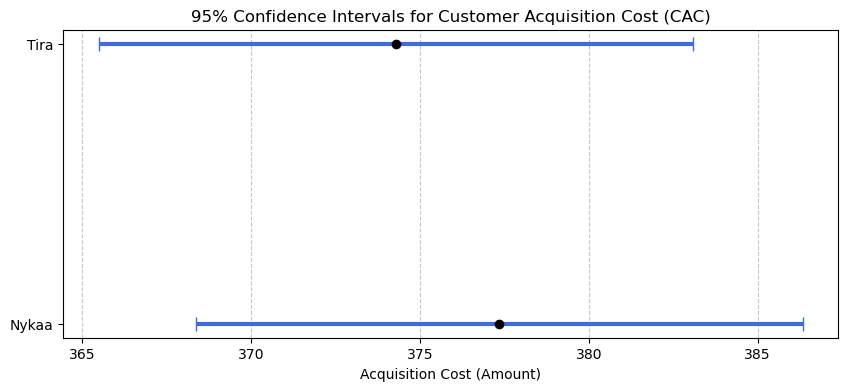

<Figure size 640x480 with 0 Axes>

In [142]:
# Data from your results
companies = ['Nykaa', 'Tira']
means = [377.35, 374.28]
# Calculate the 'distance' from mean to the interval bounds
# Nykaa: 381.84 - 372.84 = 9
# Tira: 378.67 - 369.87 = 8.8
errors = [9, 8.8] 

plt.figure(figsize=(10, 4))
plt.errorbar(means, companies, xerr=errors, fmt='o', color='black', 
             ecolor='royalblue', elinewidth=3, capsize=5)

plt.title('95% Confidence Intervals for Customer Acquisition Cost (CAC)')
plt.xlabel('Acquisition Cost (Amount)')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()
plt.savefig('c_interval_cac.png')

<h4>4. How much duartion of content on average gives high ROI , CTR, LEADS and CONVERSIONS ? (NYKAA and TIRA)  <h4>

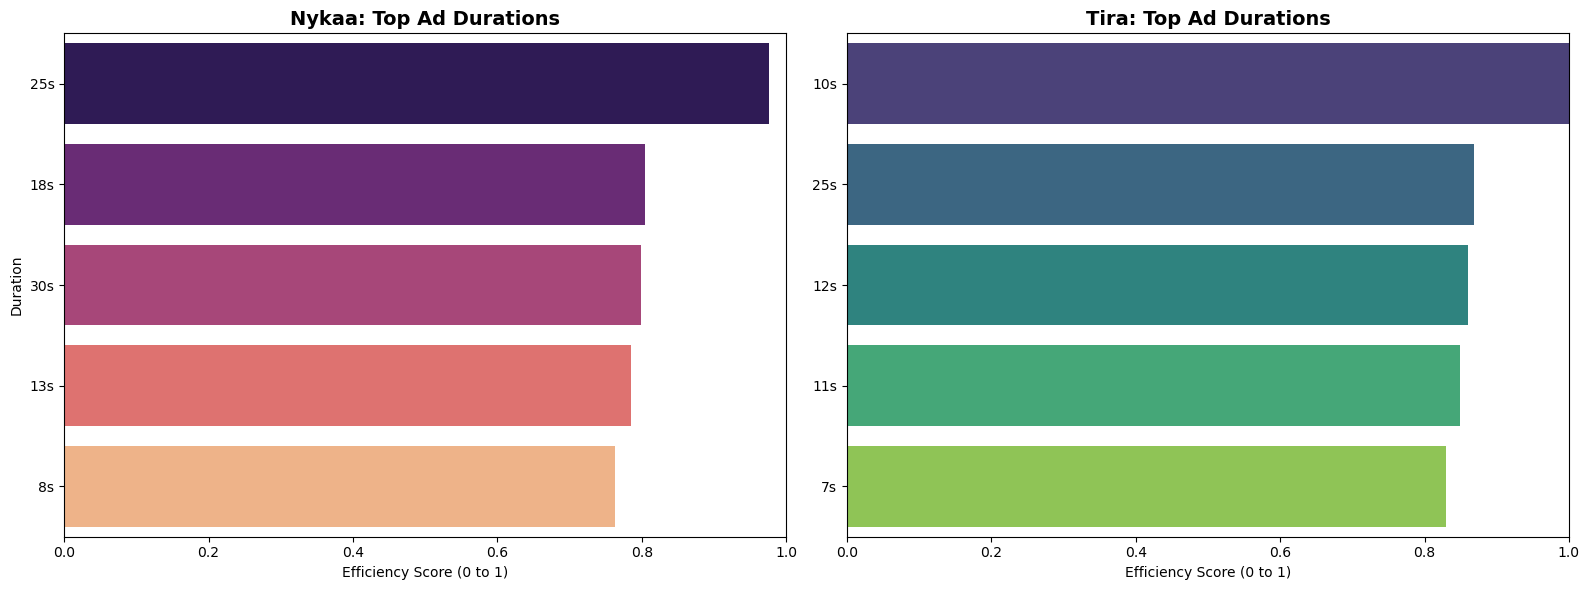

<Figure size 640x480 with 0 Axes>

In [143]:
fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharex=True)

# 1. Plot Nykaa (Left Side)
nykaa_top = nykaa_final.head(5).copy()
nykaa_top.index = nykaa_top.index.astype(str) + "s" # Label as seconds
sns.barplot(x='Total_Performance_Score', y=nykaa_top.index, 
            data=nykaa_top, palette="magma", ax=ax[0],hue=nykaa_top.index, legend=False)

ax[0].set_title('Nykaa: Top Ad Durations', fontsize=14, fontweight='bold')
ax[0].set_xlabel('Efficiency Score (0 to 1)')
ax[0].set_ylabel('Duration')

# 2. Plot Tira (Right Side)
tira_top = tira_final.head(5).copy()
tira_top.index = tira_top.index.astype(str) + "s" # Label as seconds
sns.barplot(x='Total_Performance_Score', y=tira_top.index, 
            data=tira_top, palette="viridis", ax=ax[1],hue=tira_top.index, legend=False)

ax[1].set_title('Tira: Top Ad Durations', fontsize=14, fontweight='bold')
ax[1].set_xlabel('Efficiency Score (0 to 1)')
ax[1].set_ylabel('') # Hide Y label on second plot to save space

plt.xlim(0, 1) # Crucial: Keep both on the same scale
plt.tight_layout()
plt.show()
plt.savefig('ad_duration.png')

<h4>5. What is the True Skill level (ROI) of different top 10 channel_used ? (NYKAA and TIRA) <h4>

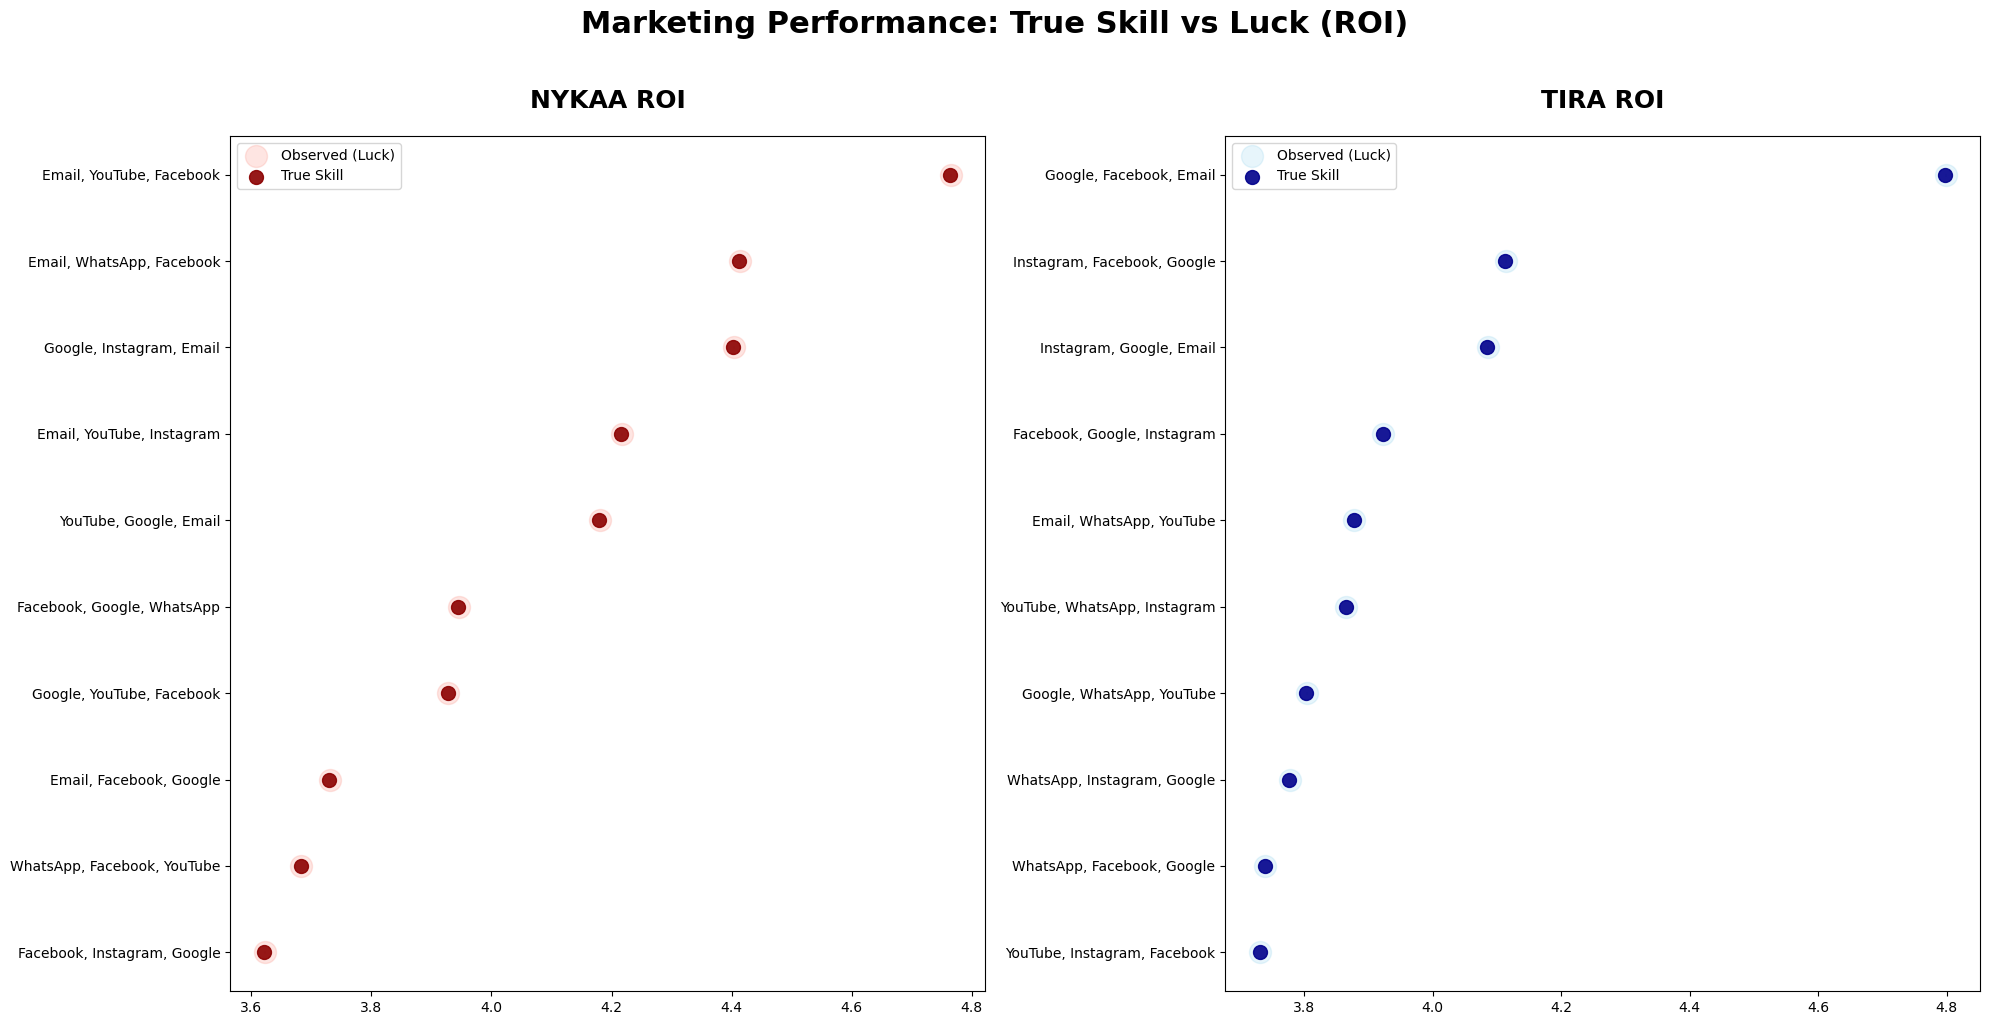

<Figure size 640x480 with 0 Axes>

In [148]:
fig, axes = plt.subplots(1, 2, figsize=(20, 10))
fig.suptitle("Marketing Performance: True Skill vs Luck (ROI)", fontsize=22, fontweight='bold', y=1.02)

# 1. NYKAA SECTION
nykaa_plot_data = top_channels.head(10).sort_values('ROI_Truth_Average')
axes[0].hlines(y=nykaa_plot_data['Channel_Used'], xmin=nykaa_plot_data['ROI_Truth_Average'], 
               xmax=nykaa_plot_data['ROI'], color='grey', alpha=0.3, linewidth=2, zorder=1)

# Observed ROI
axes[0].scatter(nykaa_plot_data['ROI'], nykaa_plot_data['Channel_Used'], 
                color='salmon', s=250, alpha=0.2, label='Observed (Luck)', zorder=2)
# True Skill
axes[0].scatter(nykaa_plot_data['ROI_Truth_Average'], nykaa_plot_data['Channel_Used'], 
                color='darkred', s=100, alpha=0.9, label='True Skill', zorder=3)

axes[0].set_title("NYKAA ROI", fontsize=18, fontweight='bold', pad=20)
axes[0].legend()

# 2. TIRA SECTION
tira_plot_data = top_channels1.head(10).sort_values('ROI_Truth_Average')
axes[1].hlines(y=tira_plot_data['Channel_Used'], xmin=tira_plot_data['ROI_Truth_Average'], 
               xmax=tira_plot_data['ROI'], color='grey', alpha=0.3, linewidth=2, zorder=1)

# Observed ROI
axes[1].scatter(tira_plot_data['ROI'], tira_plot_data['Channel_Used'], 
                color='skyblue', s=250, alpha=0.2, label='Observed (Luck)', zorder=2)
# True Skill
axes[1].scatter(tira_plot_data['ROI_Truth_Average'], tira_plot_data['Channel_Used'], 
                color='darkblue', s=100, alpha=0.9, label='True Skill', zorder=3)

axes[1].set_title("TIRA ROI", fontsize=18, fontweight='bold', pad=20)
axes[1].legend()

plt.tight_layout()
plt.show()
plt.savefig('true_roi_obsereved_roi.png')

<h4>6. Which brands ROI performance is better ? Hypothesis Testing (Independent T test)<h4>

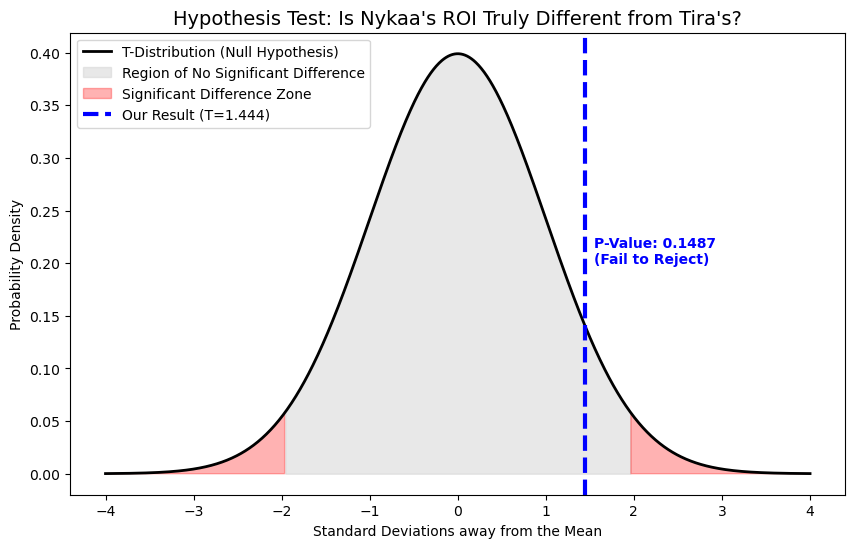

<Figure size 640x480 with 0 Axes>

In [149]:
t_stat = 1.4441
p_val = 0.1487
df = 111108 # Combined degrees of freedom from your large dataset

# Create the distribution range
x = np.linspace(-4, 4, 1000)
y = stats.t.pdf(x, df)

plt.figure(figsize=(10, 6))
plt.plot(x, y, label='T-Distribution (Null Hypothesis)', color='black', lw=2)

# Shade the 95% Confidence region (Acceptance Region)
cv = stats.t.ppf(1 - 0.025, df) # Critical value for 2-tailed test
plt.fill_between(x, y, where=(x > -cv) & (x < cv), color='lightgray', alpha=0.5, label='Region of No Significant Difference')

# Shade the Rejection Regions (The Tails)
plt.fill_between(x, y, where=(x <= -cv) | (x >= cv), color='red', alpha=0.3, label='Significant Difference Zone')

# Plot your specific T-Statistic
plt.axvline(t_stat, color='blue', linestyle='--', lw=3, label=f'Our Result (T={t_stat:.3f})')

# Annotations
plt.title("Hypothesis Test: Is Nykaa's ROI Truly Different from Tira's?", fontsize=14)
plt.xlabel("Standard Deviations away from the Mean")
plt.ylabel("Probability Density")
plt.legend()

plt.text(t_stat + 0.1, 0.2, f'P-Value: {p_val:.4f}\n(Fail to Reject)', color='blue', fontweight='bold')

plt.show()
plt.savefig('hypothesis_roi.png')

<h4>7. Based on Average Metrics like ROI , CTR , Conversions , Waste Leads Who Will Perform better in the 10,000 simulations.(Monte Carlo Simulation)<h4>

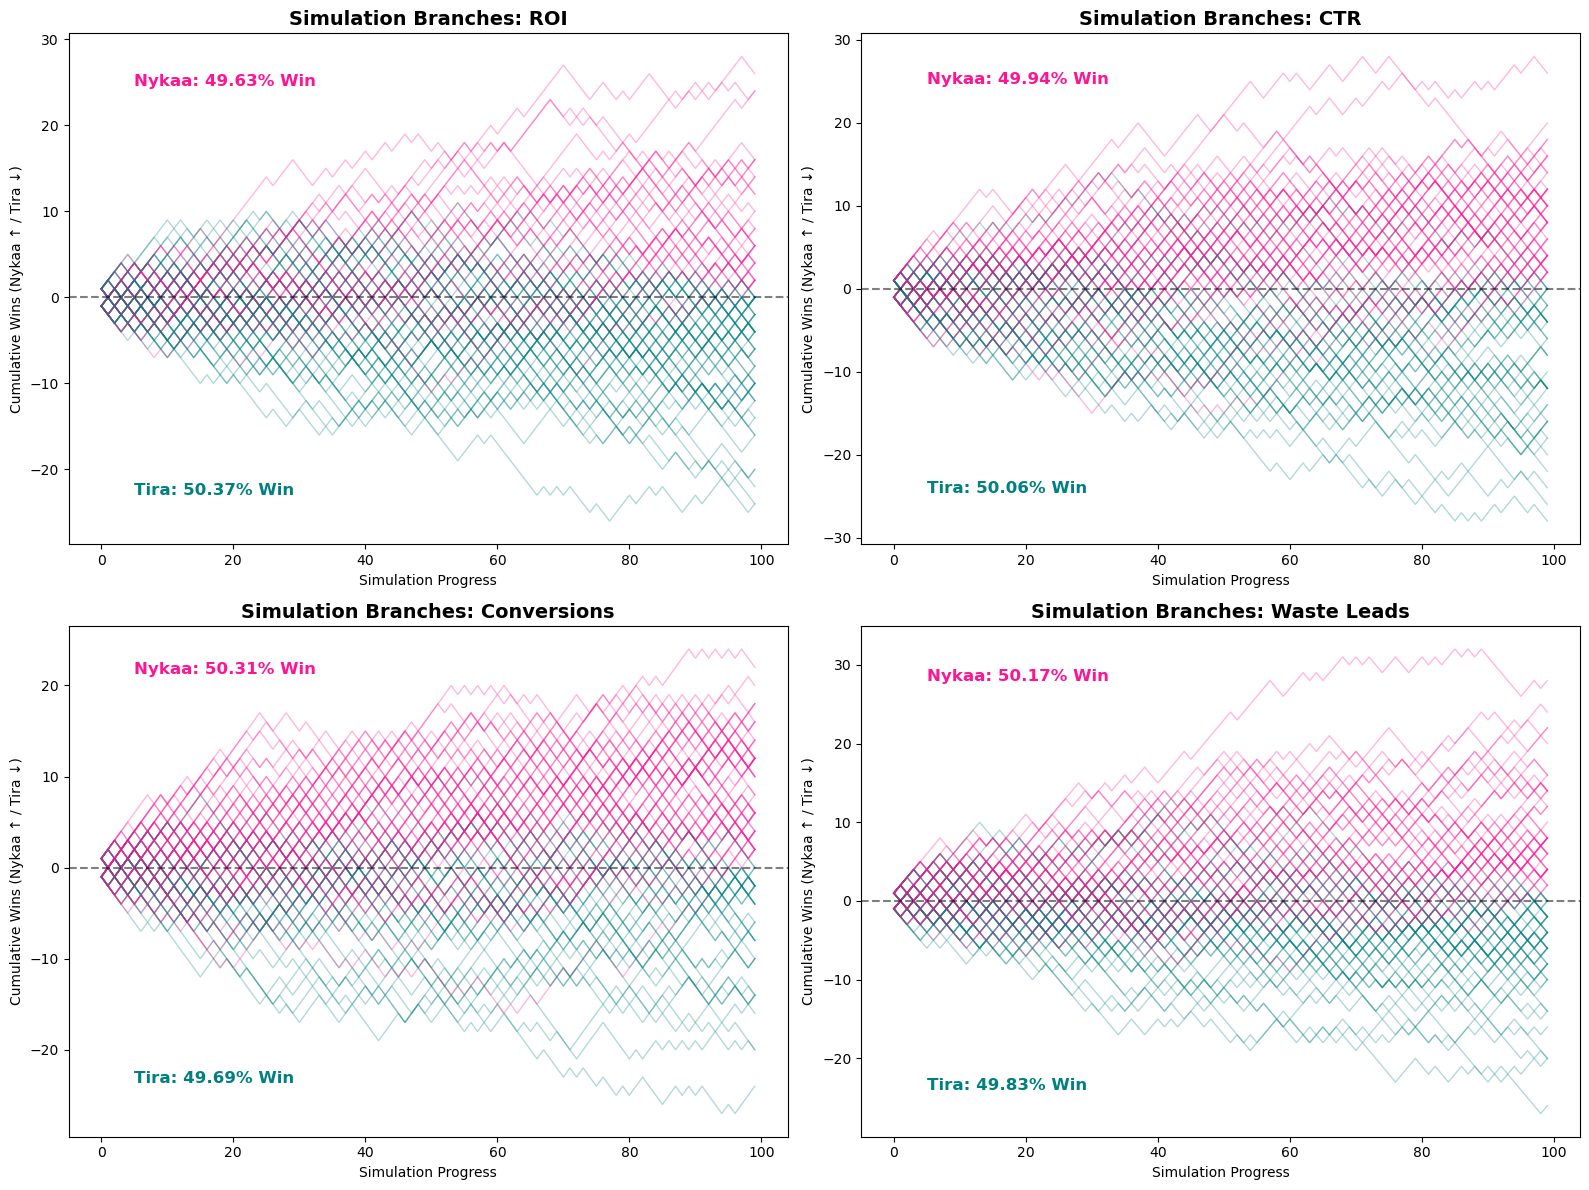

In [150]:
# Using the win percentages from the user's notebook output (these all values will be remain close to 50/50)
# ROI: Nykaa 49.63, Tira 50.37
# CTR: Nykaa 49.94, Tira 50.06
# Conversions: Nykaa 50.31, Tira 49.69
# Waste Leads: Nykaa 50.17, Tira 49.83

metrics = ['ROI', 'CTR', 'Conversions', 'Waste Leads']
nykaa_win_probs = [0.4963, 0.4994, 0.5031, 0.5017]

n_paths = 100
steps = 100 # Total length of the path

fig, axes = plt.subplots(2, 2, figsize=(16, 12))
axes = axes.flatten()

for i, (metric, p) in enumerate(zip(metrics, nykaa_win_probs)):
    ax = axes[i]
    
    # Generate random paths
    # Each step is +1 (Nykaa wins) or -1 (Tira wins)
    for _ in range(n_paths):
        # Sample steps based on the probability p
        path_steps = np.random.choice([1, -1], size=steps, p=[p, 1-p])
        path = np.cumsum(path_steps)
        
        # Color based on who ends up ahead
        color = 'deeppink' if path[-1] > 0 else 'teal'
        ax.plot(range(steps), path, color=color, alpha=0.3, linewidth=1)
    
    # Add central line
    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    
    # Labels and Titles
    ax.set_title(f"Simulation Branches: {metric}", fontsize=14, fontweight='bold')
    ax.set_ylabel("Cumulative Wins (Nykaa ↑ / Tira ↓)")
    ax.set_xlabel("Simulation Progress")
    
    # Text annotation for final win %
    ax.text(steps*0.05, ax.get_ylim()[1]*0.8, f"Nykaa: {p*100:.2f}% Win", color='deeppink', fontweight='bold', fontsize=12)
    ax.text(steps*0.05, ax.get_ylim()[0]*0.8, f"Tira: {(1-p)*100:.2f}% Win", color='teal', fontweight='bold', fontsize=12)

plt.tight_layout()
plt.savefig('monte_carlo_branches.png')